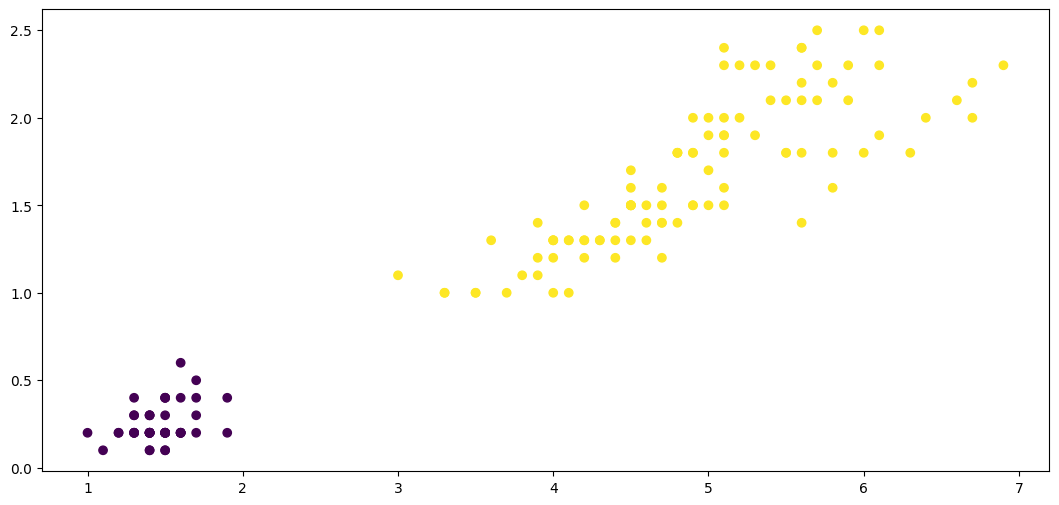

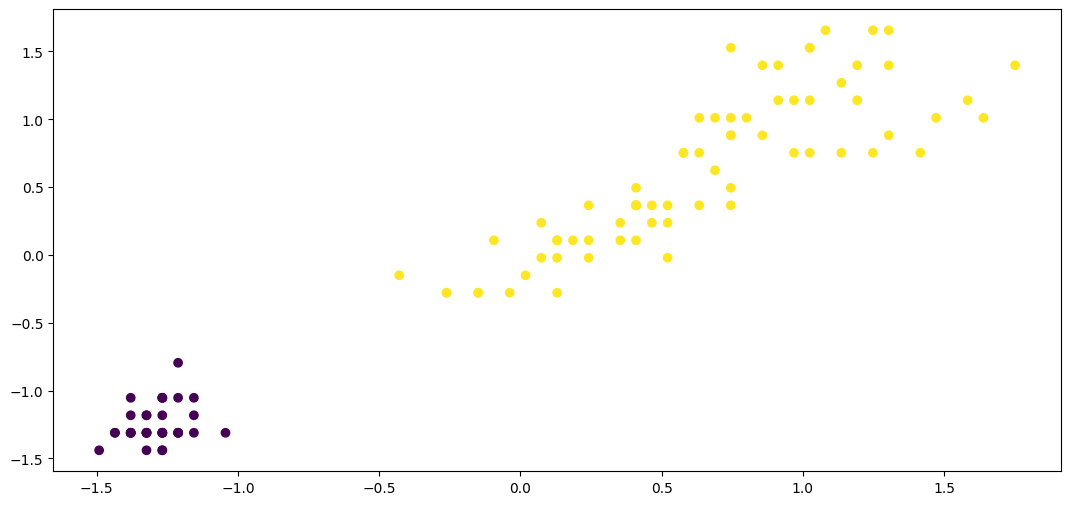

In [1]:
import numpy as np
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
iris = load_iris() 
data=iris.data[:,(2,3)]
labels= iris.target
for i in range (len(labels)):
    if labels[i]== 2:
        labels[i]= 1
      
plt.figure(figsize=(13,6))
plt.scatter(data[:,0],data[:,1],c=labels)
plt.show()
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=8)
scaler = StandardScaler()
scaler.fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

plt.figure(figsize=(13,6))
plt.scatter(X_train_std[:,0],X_train_std[:,1],c=y_train)
#plt.show()


In [2]:

def perceptron(inputs,output_true,theta,alpha,w,nb_epoch):
    y=np.ones(len(output_true))
    for ep in range (nb_epoch): 
        for i in range (len(output_true)):
            z=np.dot(inputs,w)   
            if round(z[i],1)>= theta:
                y[i]=1
                if y [i] != output_true[i]:
                    for j in range (len(w)):
                        w[j]=w[j]+(alpha*(output_true[i] - y[i])*inputs[i,j])                        
                             
            elif round(z[i],1)<theta:
                y[i]=0
                if y[i]!= output_true [i]:
                    for j in range (len(w)):
                        w[j]=w[j]+(alpha*(output_true[i] - y[i])*inputs[i,j])
    print("epoch number",ep+1)
    print("y=",y)
    print("w=",w)
    print("The error is equal to:",output_true-y,)
    #calculate accuracy
    error= output_true-y
    nb_true=0
    for i in range(len(error)):
        if error[i]==0:
            nb_true=nb_true+1
    accuracy=(nb_true*100)/len(output_true)
    #accuracy= ((len (output_true)-1)*100)/len (output_true)
    print("The accuracy is equal to:", accuracy, "percent")

In [3]:
perceptron(X_train_std,y_train,0,0.1,np.array([0.3,0.2]),30)

epoch number 30
y= [0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0.
 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1.
 1. 1. 0. 1. 1. 1. 1. 1. 1.]
w= [0.07402651 0.01559918]
The error is equal to: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
The accuracy is equal to: 100.0 percent


In [4]:
#do the test

def test(inputs,output_true,w,theta):
    y=np.ones(len(output_true))
    for i in range (len(output_true)):
        z=np.dot(inputs ,w)   
        if round(z[i],1)>= theta:
            y[i]=1
        else:
            y[i]=0
    error= y_test - y
    
    #calculate accuracy
    nb_true=0
    for i in range(len(error)):
        if error[i]==0:
            nb_true=nb_true+1
    accuracy=(nb_true*100)/len(y_test)
            
    print("True outputs  are:", y_test)
    print("Our model's outputs are:",y)
    print("The error is equal to:", error)
    print("accuracy is equal to:", accuracy, "percent") 
    

In [5]:
test(X_test_std ,y_test,np.array([0.07,0.015]),0)

True outputs  are: [0 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 1 1 1
 1 0 1 1 0 1 1 1]
Our model's outputs are: [0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1.]
The error is equal to: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
accuracy is equal to: 100.0 percent
